## Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import seaborn as sns
import BanglaProcess as bp

In [2]:
# Warnings supression
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Loadin Datasets

In [ ]:
train_data_path = ''
dev_data_path = ''
dev_test_data_path = ''

In [4]:
train_df = pd.read_csv(train_data_path, sep='\t', keep_default_na=False)
dev_df = pd.read_csv(dev_data_path, sep='\t', keep_default_na=False)
dev_test_df = pd.read_csv(dev_test_data_path, sep='\t', keep_default_na=False)

In [5]:
def analyze_dataframe(df, name):
    """
    Analyzes a pandas DataFrame and prints its shape, size, and info.

    Args:
        df (pandas.DataFrame): The DataFrame to analyze.
        name (str): The name of the DataFrame.
    """
    print(f"========{name} DataFrame Analysis=========")
    print("Shape:", df.shape)
    print("Size:", df.size)
    print("Description", df.describe())

# Example usage with your dataframes
analyze_dataframe(train_df, "Train")
analyze_dataframe(dev_df, "Dev")
analyze_dataframe(dev_test_df, "Dev Test")

========Train DataFrame Analysis=========
Shape: (35522, 5)
Size: 177610
Description                   id
count   35522.000000
mean   470131.934435
std    271256.805054
min        96.000000
25%    235179.000000
50%    470483.000000
75%    705906.250000
max    939762.000000
========Dev DataFrame Analysis=========
Shape: (2512, 5)
Size: 12560
Description                   id
count    2512.000000
mean   480864.673567
std    272206.796753
min       567.000000
25%    244570.250000
50%    487492.500000
75%    715322.000000
max    939569.000000
========Dev Test DataFrame Analysis=========
Shape: (2512, 2)
Size: 5024
Description                   id
count    2512.000000
mean   473769.031051
std    275347.863162
min        91.000000
25%    236288.500000
50%    470729.000000
75%    718091.750000
max    938949.000000


In [6]:
def text_cleaning(text):
  text = bp.remove_punc(text)
  # text = bp.remove_digits(text)
  text = bp.remove_nonBangla(text)
  text = bp.remove_emoticons(text)
  return text

In [7]:
# train_df['cleaned_text'] = train_df['text'].apply(text_cleaning)
# dev_df['cleaned_text'] = dev_df['text'].apply(text_cleaning)

In [8]:
def show_text_cleaning_differences(df):
  """
  Prints the original and cleaned text for rows where their lengths are different.

  Args:
    df (pandas.DataFrame): The input DataFrame with 'text' and 'cleaned_text' columns.
  """
  print("Showing rows where original text and cleaned text lengths are different:")
  for index, row in df.iterrows():
    if len(row['text']) != len(row['cleaned_text']):
      print(f"\nRow Index: {index}")
      print(f"Original Text: {row['text']}")
      print(f"Cleaned Text: {row['cleaned_text']}")

# show_text_cleaning_differences(train_df)
# show_text_cleaning_differences(dev_df)

## Frequency Length Distribution

In [9]:
def add_text_length_column(df):
  """
  Adds a 'text_length' column to the DataFrame containing the length of the 'text' column.

  Args:
    df (pandas.DataFrame): The input DataFrame with a 'text' column.

  Returns:
    pandas.DataFrame: The DataFrame with the added 'text_length' column.
  """
  df['text_length'] = df['text'].apply(len)
  return df

# Example usage with your dataframes
train_df = add_text_length_column(train_df)
dev_df = add_text_length_column(dev_df)
# dev_test_df = add_text_length_column(dev_test_df)

print("Train DataFrame with 'text_length' column:")
display(train_df.head())
print("\nDev DataFrame with 'text_length' column:")
display(dev_df.head())

Train DataFrame with 'text_length' column:


,id,text,hate_type,hate_severity,to_whom,text_length
0,147963,ধন্যবাদ বর্ডার গার্ড দেরকে এভাবে পাহারা দিতে হ...,None,Little to None,None,102
1,214275,ছোটবেলায় অনেক কষ্ট করে কিছু গালাগালি শিখছিলাম...,None,Little to None,None,170
2,849172,অতিরিক্ত এ নিজেকে বাদুর বানাইয়া ফেলছেন রে,Abusive,Little to None,Individual,41
3,821985,চিন ভারত রাশিয়া এই তিন দেশ এক থাকলে বিশ্বকে শা...,None,Little to None,None,58
4,477288,এটার বিচার কে করবেযে বিচার করবে সেই তো হলো এই ...,Abusive,Severe,Individual,67



Dev DataFrame with 'text_length' column:


,id,text,hate_type,hate_severity,to_whom,text_length
0,166449,ইন্ডিয়া কি মাছ ধরা বন্ধ রাখছেএক নদীতে দুইনীতি ...,Political Hate,Mild,Society,54
1,267692,লক্ষ টাকা ঘুষ দিয়ে অযোগ্য আর দায়িত্বহীন মানস...,Abusive,Little to None,Organization,142
2,184031,ওহা ভবনের দালাল,None,Little to None,None,15
3,939131,আর কতো শিখবে আমার সোনার ছেলেরা এগুলো কে টাকা দ...,Abusive,Mild,Individual,121
4,210284,কি সাংঘাতিক ভাই রে তুই,Abusive,Little to None,Individual,22


In [10]:
def plot_length_distribution(df, columns, title_prefix):
    """
    Generates bar charts showing the text length distribution for specified columns.

    Args:
        df (pandas.DataFrame): The input DataFrame with 'text_length' column.
        columns (list): A list of column names to group by.
        title_prefix (str): Prefix for the plot titles.
    """
    for col in columns:
        if col in df.columns:
            plt.figure(figsize=(12, 6))
            ax = sns.barplot(x=col, y='text_length', data=df, estimator=np.mean, ci=None)
            plt.title(f'{title_prefix} - Average Text Length by {col}')
            plt.ylabel('Average Text Length')
            plt.xlabel(col)
            plt.xticks(rotation=45, ha='right')
            plt.tight_layout()

            # Add text labels to the bars
            for p in ax.patches:
                ax.annotate(f'{p.get_height():.0f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='center', xytext=(0, 5), textcoords='offset points')

            plt.show()
        else:
            print(f"Column '{col}' not found in the DataFrame.")

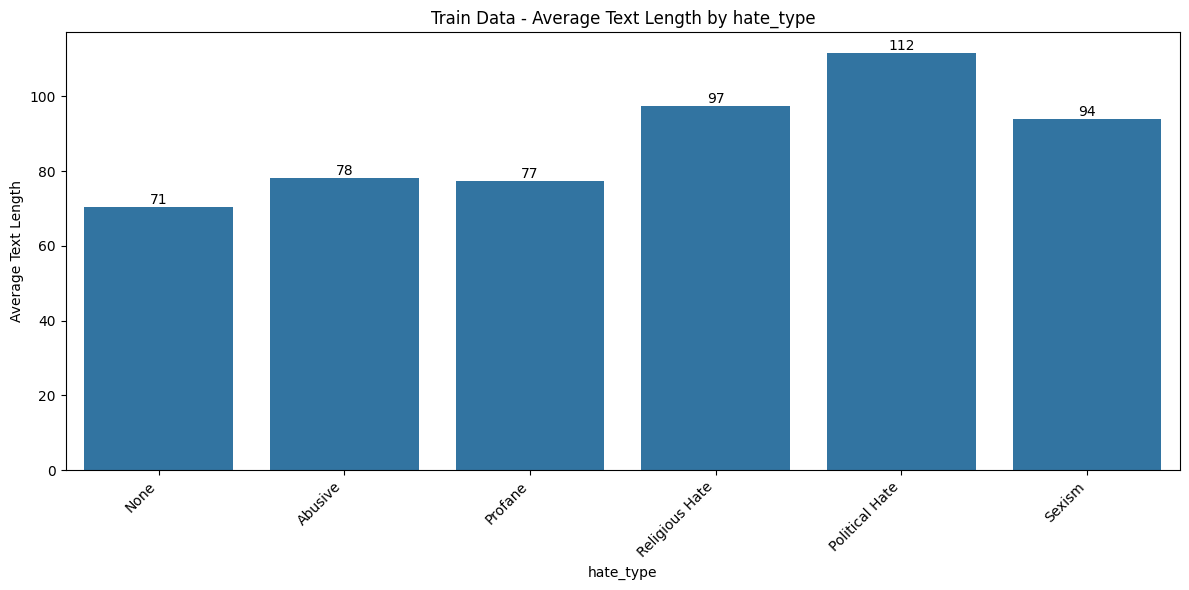

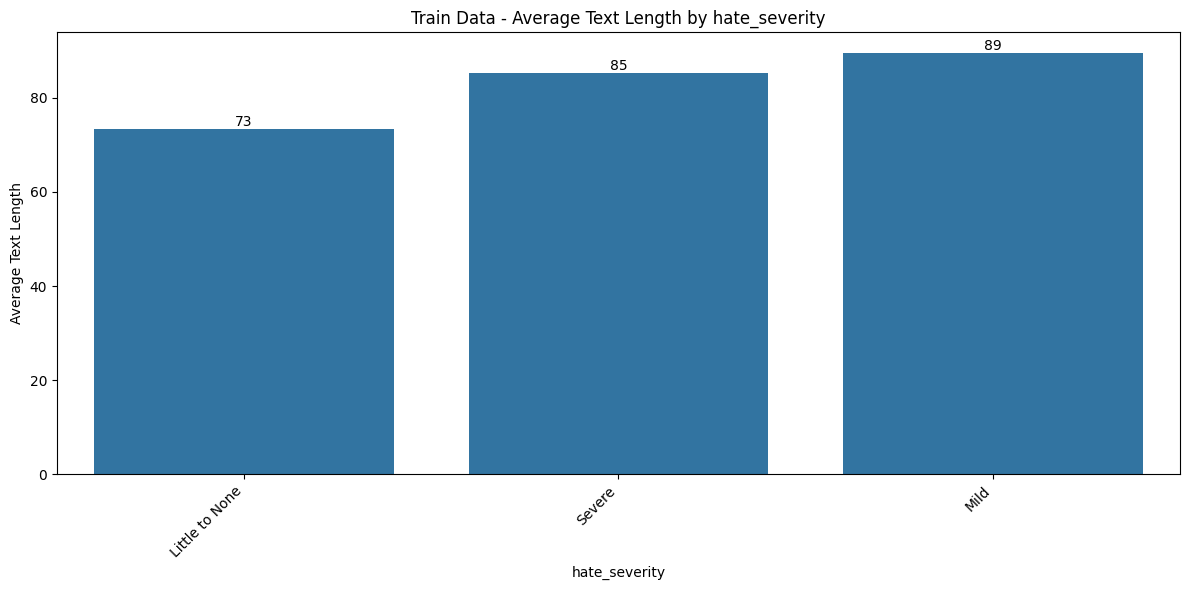

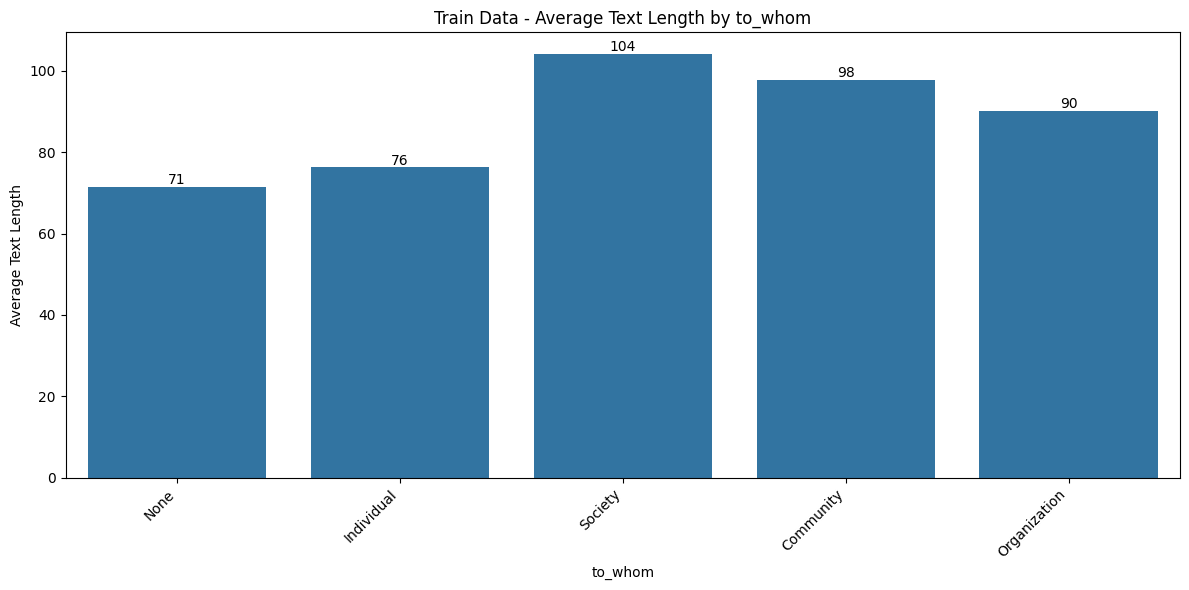

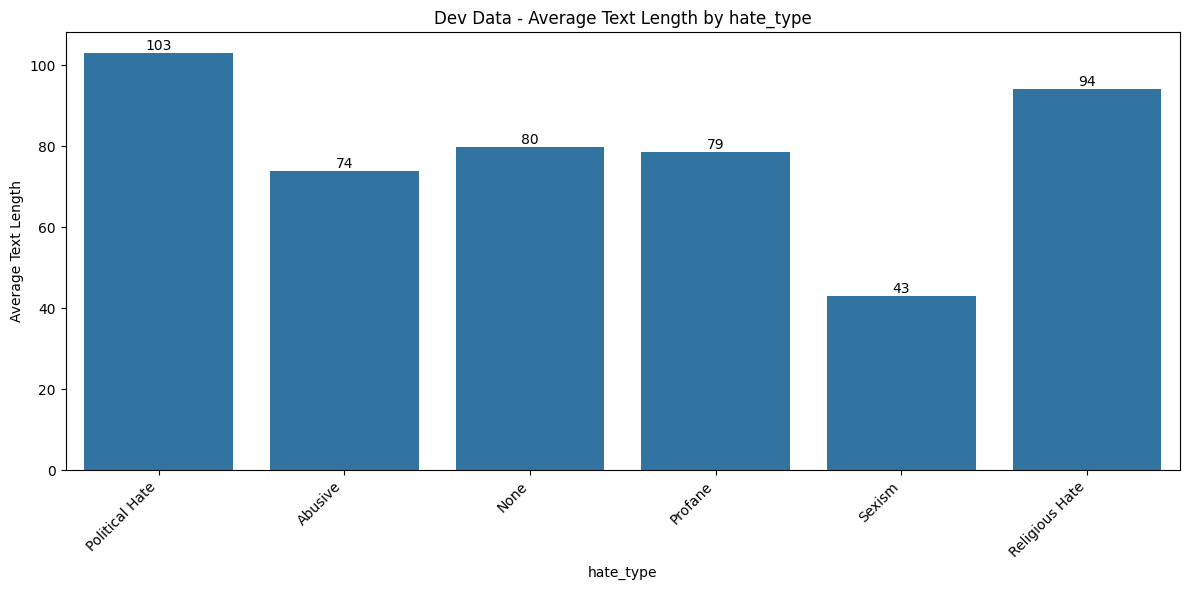

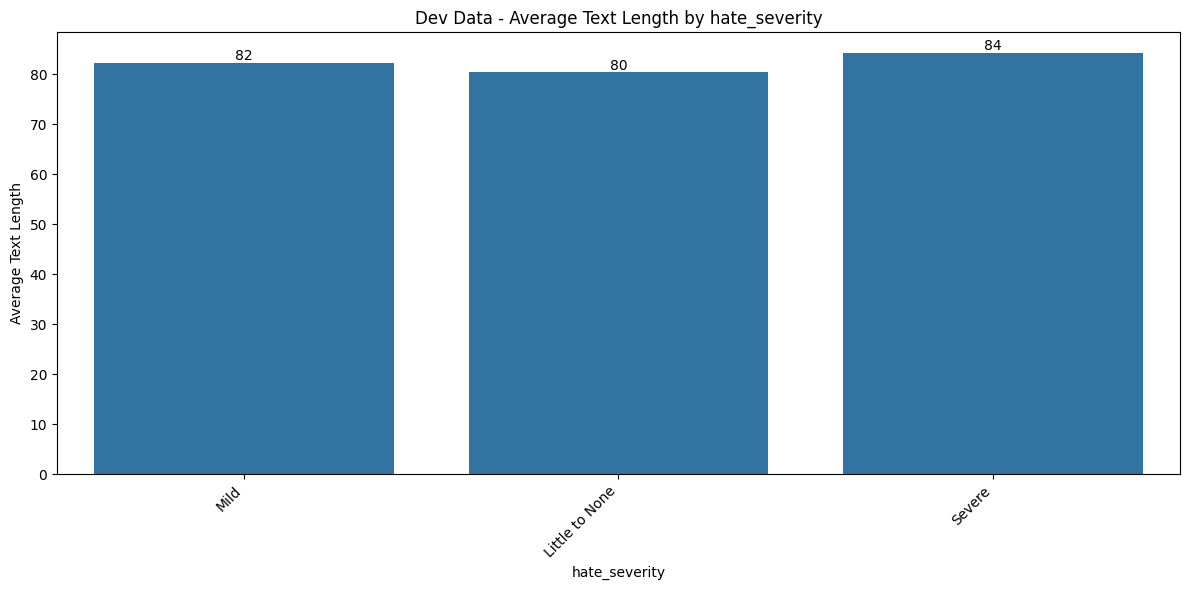

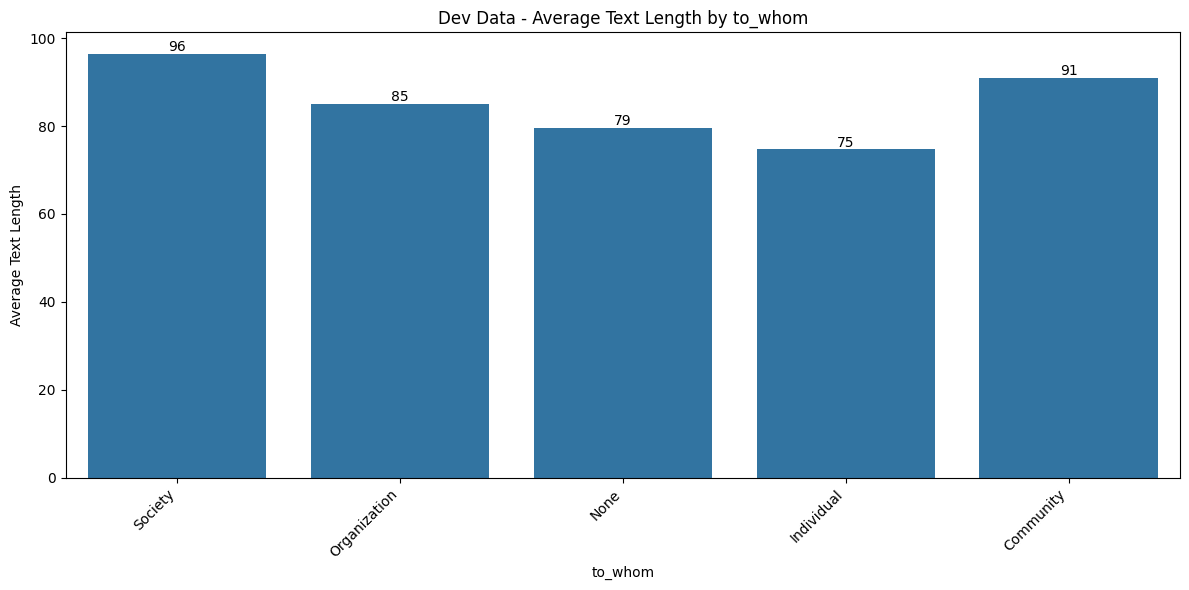

In [11]:
# Specify the columns to analyze
columns_to_analyze = ['hate_type', 'hate_severity', 'to_whom']

# Plot for train_df
plot_length_distribution(train_df, columns_to_analyze, "Train Data")

# Plot for dev_df
plot_length_distribution(dev_df, columns_to_analyze, "Dev Data")

## Find label names

In [12]:
def show_unique_labels(df, columns):
    """
    Prints the unique labels for the specified columns in a DataFrame.

    Args:
        df (pandas.DataFrame): The input DataFrame.
        columns (list): A list of column names to show unique labels for.
    """
    print("======== Unique Labels Analysis =========")
    for col in columns:
        if col in df.columns:
            print(f"\nUnique labels for '{col}':")
            display(df[col].unique())
        else:
            print(f"\nColumn '{col}' not found in the DataFrame.")

columns_to_check = ['to_whom', 'hate_severity', 'hate_type']

print("--- Train DataFrame ---")
show_unique_labels(train_df, columns_to_check)

print("\n--- Dev DataFrame ---")
show_unique_labels(dev_df, columns_to_check)

--- Train DataFrame ---
======== Unique Labels Analysis =========

Unique labels for 'to_whom':


array(['None', 'Individual', 'Society', 'Community', 'Organization'],
      dtype=object)


Unique labels for 'hate_severity':


array(['Little to None', 'Severe', 'Mild'], dtype=object)


Unique labels for 'hate_type':


...

array(['Society', 'Organization', 'None', 'Individual', 'Community'],
      dtype=object)


Unique labels for 'hate_severity':


array(['Mild', 'Little to None', 'Severe'], dtype=object)


Unique labels for 'hate_type':


array(['Political Hate', 'Abusive', 'None', 'Profane', 'Sexism',
       'Religious Hate'], dtype=object)

## Load and preprocess data for Transformer


In [13]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer

# 1. Define dictionaries to map labels to integer IDs
hate_type_map = {label: i for i, label in enumerate(train_df['hate_type'].unique())}
hate_severity_map = {label: i for i, label in enumerate(train_df['hate_severity'].unique())}
to_whom_map = {label: i for i, label in enumerate(train_df['to_whom'].unique())}

# 2. Replace string labels with integer IDs
train_df['hate_type'] = train_df['hate_type'].map(hate_type_map)
train_df['hate_severity'] = train_df['hate_severity'].map(hate_severity_map)
train_df['to_whom'] = train_df['to_whom'].map(to_whom_map)

dev_df['hate_type'] = dev_df['hate_type'].map(hate_type_map)
dev_df['hate_severity'] = dev_df['hate_severity'].map(hate_severity_map)
dev_df['to_whom'] = dev_df['to_whom'].map(to_whom_map)

# 3. Load the banglabert tokenizer
tokenizer = AutoTokenizer.from_pretrained('csebuetnlp/banglabert_large')

# 4. Tokenize the 'text' column
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

train_tokenized = train_df.apply(tokenize_function, axis=1)
dev_tokenized = dev_df.apply(tokenize_function, axis=1)
dev_test_tokenized = dev_test_df.apply(tokenize_function, axis=1)

# Convert the tokenized results into a format suitable for PyTorch
train_encodings = list(train_tokenized)
dev_encodings = list(dev_tokenized)
dev_test_encodings = list(dev_test_tokenized)


# 5. Create custom PyTorch Dataset classes
class HateSpeechDataset(Dataset):
    def __init__(self, encodings, hate_type_labels=None, hate_severity_labels=None, to_whom_labels=None):
        self.encodings = encodings
        self.hate_type_labels = hate_type_labels
        self.hate_severity_labels = hate_severity_labels
        self.to_whom_labels = to_whom_labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val) for key, val in self.encodings[idx].items()}
        if self.hate_type_labels is not None:
            item['hate_type_labels'] = torch.tensor(self.hate_type_labels[idx])
        if self.hate_severity_labels is not None:
            item['hate_severity_labels'] = torch.tensor(self.hate_severity_labels[idx])
        if self.to_whom_labels is not None:
            item['to_whom_labels'] = torch.tensor(self.to_whom_labels[idx])
        return item

    def __len__(self):
        return len(self.encodings)

# 6. Instantiate the custom Dataset classes
train_dataset = HateSpeechDataset(train_encodings, train_df['hate_type'].tolist(), train_df['hate_severity'].tolist(), train_df['to_whom'].tolist())
dev_dataset = HateSpeechDataset(dev_encodings, dev_df['hate_type'].tolist(), dev_df['hate_severity'].tolist(), dev_df['to_whom'].tolist())
dev_test_dataset = HateSpeechDataset(dev_test_encodings)

# 7. Create PyTorch DataLoaders
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
dev_dataloader = DataLoader(dev_dataset, batch_size=16)
dev_test_dataloader = DataLoader(dev_test_dataset, batch_size=16)

print("Label mappings:")
print("Hate Type Map:", hate_type_map)
print("Hate Severity Map:", hate_severity_map)
print("To Whom Map:", to_whom_map)
print("\nTrain DataLoader size:", len(train_dataloader))
print("Dev DataLoader size:", len(dev_dataloader))
print("Dev Test DataLoader size:", len(dev_test_dataloader))

Label mappings:
Hate Type Map: {'None': 0, 'Abusive': 1, 'Profane': 2, 'Religious Hate': 3, 'Political Hate': 4, 'Sexism': 5}
Hate Severity Map: {'Little to None': 0, 'Severe': 1, 'Mild': 2}
To Whom Map: {'None': 0, 'Individual': 1, 'Society': 2, 'Community': 3, 'Organization': 4}

Train DataLoader size: 2221
Dev DataLoader size: 157
Dev Test DataLoader size: 157


## Define multitask model


In [14]:
import torch.nn as nn
from transformers import AutoModel

class MultitaskModel(nn.Module):
    def __init__(self, banglabert_model, num_hate_type_labels, num_hate_severity_labels, num_to_whom_labels):
        super().__init__()
        self.muril = banglabert_model
        hidden_size = banglabert_model.config.hidden_size

        self.hate_type_classifier = nn.Linear(hidden_size, num_hate_type_labels)
        self.hate_severity_classifier = nn.Linear(hidden_size, num_hate_severity_labels)
        self.to_whom_classifier = nn.Linear(hidden_size, num_to_whom_labels)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None, hate_type_labels=None, hate_severity_labels=None, to_whom_labels=None):
        outputs = self.muril(
            input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        # Use the hidden state of the first token (CLS token) instead of pooler_output
        pooled_output = outputs.last_hidden_state[:, 0]

        hate_type_logits = self.hate_type_classifier(pooled_output)
        hate_severity_logits = self.hate_severity_classifier(pooled_output)
        to_whom_logits = self.to_whom_classifier(pooled_output)

        loss = {}
        if hate_type_labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss['hate_type_loss'] = loss_fct(hate_type_logits.view(-1, self.hate_type_classifier.out_features), hate_type_labels.view(-1))
        if hate_severity_labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss['hate_severity_loss'] = loss_fct(hate_severity_logits.view(-1, self.hate_severity_classifier.out_features), hate_severity_labels.view(-1))
        if to_whom_labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss['to_whom_loss'] = loss_fct(to_whom_logits.view(-1, self.to_whom_classifier.out_features), to_whom_labels.view(-1))

        return {
            'hate_type_logits': hate_type_logits,
            'hate_severity_logits': hate_severity_logits,
            'to_whom_logits': to_whom_logits,
            'loss': loss
        }

# Load the pre-trained Muril model
banglabert_model = AutoModel.from_pretrained('csebuetnlp/banglabert')

# Get the number of unique labels from the mappings
num_hate_type_labels = len(hate_type_map)
num_hate_severity_labels = len(hate_severity_map)
num_to_whom_labels = len(to_whom_map)

# Instantiate the custom multitask model
model = MultitaskModel(banglabert_model, num_hate_type_labels, num_hate_severity_labels, num_to_whom_labels)

print("Multitask model instantiated with custom classification heads.")
print("Number of hate_type labels:", num_hate_type_labels)
print("Number of hate_severity labels:", num_hate_severity_labels)
print("Number of to_whom labels:", num_to_whom_labels)

Multitask model instantiated with custom classification heads.
Number of hate_type labels: 6
Number of hate_severity labels: 3
Number of to_whom labels: 5


## Set up training


In [15]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=1e-5)

print("AdamW optimizer instantiated.")

AdamW optimizer instantiated.


## Train the model


In [16]:
from tqdm.auto import tqdm
import gc

# 1. Define the number of training epochs.
num_epochs = 3  # You can adjust this number

# 2. Set the device to GPU if available, otherwise use CPU.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# 3. Move the model to the selected device.
model.to(device)

# Initialize best validation loss for saving the model
best_val_loss = float('inf')

# 4. Iterate through the epochs.
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    # 5. For each epoch, set the model to training mode and iterate through the train_dataloader.
    model.train()
    train_loss = 0.0
    for batch in tqdm(train_dataloader, desc="Training"):
        # Move batch data to the device
        batch = {k: v.to(device) for k, v in batch.items()}

        # Perform forward pass
        outputs = model(**batch)

        # Calculate the total loss (sum of individual task losses)
        total_loss = sum(outputs['loss'].values())

        # Perform backpropagation
        optimizer.zero_grad()
        total_loss.backward()

        # Update the model parameters
        optimizer.step()

        train_loss += total_loss.item()

    avg_train_loss = train_loss / len(train_dataloader)

    # 7. After each training epoch, set the model to evaluation mode and iterate through the dev_dataloader.
    model.eval()
    val_hate_type_loss = 0.0
    val_hate_severity_loss = 0.0
    val_to_whom_loss = 0.0
    val_total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(dev_dataloader, desc="Validation"):
            # Move batch data to the device
            batch = {k: v.to(device) for k, v in batch.items()}

            # Perform forward pass to get the logits and losses
            outputs = model(**batch)

            # Accumulate the validation losses for each task
            val_hate_type_loss += outputs['loss']['hate_type_loss'].item()
            val_hate_severity_loss += outputs['loss']['hate_severity_loss'].item()
            val_to_whom_loss += outputs['loss']['to_whom_loss'].item()
            val_total_loss += sum(outputs['loss'].values()).item()


    # 9. Calculate the average validation loss for each task and the total average validation loss for the epoch.
    avg_val_hate_type_loss = val_hate_type_loss / len(dev_dataloader)
    avg_val_hate_severity_loss = val_hate_severity_loss / len(dev_dataloader)
    avg_val_to_whom_loss = val_to_whom_loss / len(dev_dataloader)
    avg_val_total_loss = val_total_loss / len(dev_dataloader)

    # 10. Print the training and validation losses for each epoch.
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Validation Losses:")
    print(f"  Hate Type: {avg_val_hate_type_loss:.4f}")
    print(f"  Hate Severity: {avg_val_hate_severity_loss:.4f}")
    print(f"  To Whom: {avg_val_to_whom_loss:.4f}")
    print(f"  Total Validation Loss: {avg_val_total_loss:.4f}")

    # 11. (Optional) Save the model checkpoint if the total validation loss improves.
    if avg_val_total_loss < best_val_loss:
        best_val_loss = avg_val_total_loss
        # torch.save(model.state_dict(), 'best_multitask_model.pth')
        print("Validation loss improved. Model checkpoint saved.")

    # Clear cache
    del batch, outputs, total_loss
    if torch.cuda.is_available():
      torch.cuda.empty_cache()
    gc.collect()

print("\nTraining finished.")

Using device: cuda



Epoch 1/3


Training:   0%|          | 0/2221 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 2.4140
Validation Losses:
  Hate Type: 0.7608
  Hate Severity: 0.6430
  To Whom: 0.7805
  Total Validation Loss: 2.1843
Validation loss improved. Model checkpoint saved.


...


Epoch 3/3


Training:   0%|          | 0/2221 [00:00<?, ?it/s]

Validation:   0%|          | 0/157 [00:00<?, ?it/s]

Train Loss: 1.7585
Validation Losses:
  Hate Type: 0.7418
  Hate Severity: 0.6450
  To Whom: 0.7954
  Total Validation Loss: 2.1821



Training finished.


## Make Predictions

In [17]:
# Inverse mappings to convert integer IDs back to labels
hate_type_inverse_map = {v: k for k, v in hate_type_map.items()}
hate_severity_inverse_map = {v: k for k, v in hate_severity_map.items()}
to_whom_inverse_map = {v: k for k, v in to_whom_map.items()}

# Set the model to evaluation mode
model.eval()

# Lists to store predictions
all_hate_type_preds = []
all_hate_severity_preds = []
all_to_whom_preds = []

# Iterate through the dev_test_dataloader
with torch.no_grad():
    for batch in tqdm(dev_test_dataloader, desc="Predicting"):
        # Move batch data to the device
        batch = {k: v.to(device) for k, v in batch.items()}

        # Perform forward pass to get the logits
        outputs = model(**batch)

        # Get predictions for each task
        hate_type_preds = torch.argmax(outputs['hate_type_logits'], dim=-1)
        hate_severity_preds = torch.argmax(outputs['hate_severity_logits'], dim=-1)
        to_whom_preds = torch.argmax(outputs['to_whom_logits'], dim=-1)

        # Extend the lists with predictions
        all_hate_type_preds.extend(hate_type_preds.cpu().numpy())
        all_hate_severity_preds.extend(hate_severity_preds.cpu().numpy())
        all_to_whom_preds.extend(to_whom_preds.cpu().numpy())

# Convert predicted integer IDs back to original labels
predicted_hate_type_labels = [hate_type_inverse_map[pred] for pred in all_hate_type_preds]
predicted_hate_severity_labels = [hate_severity_inverse_map[pred] for pred in all_hate_severity_preds]
predicted_to_whom_labels = [to_whom_inverse_map[pred] for pred in all_to_whom_preds]

# Create a DataFrame with the predictions and original text
predictions_df = pd.DataFrame({
    'id': dev_test_df['id'], # Include the original IDs
    'text': dev_test_df['text'], # Include original text for context
    'predicted_hate_type': predicted_hate_type_labels,
    'predicted_hate_severity': predicted_hate_severity_labels,
    'predicted_to_whom': predicted_to_whom_labels
})

print("\nPredictions on dev_test data:")
display(predictions_df.head())

Predicting:   0%|          | 0/157 [00:00<?, ?it/s]


Predictions on dev_test data:


,id,text,predicted_hate_type,predicted_hate_severity,predicted_to_whom
0,879187,শুভ কামনা রইল বাংলাদেশ জন্য ইনশাআল্লাহ জয় হবে,None,Little to None,None
1,316919,গোয়া মারা দিয়ে আছে বাংলাদেশ মাদারচোদ নিউজ করে ...,Profane,Severe,Organization
2,916242,ভাইয়া আপনি অভিনেতা হইয়েন না না হলে সবাই বাচ্...,Abusive,Little to None,None
3,786824,আমাদেরো তাই দেখছি,None,Little to None,None
4,47284,পুলিশ কতটা টাকা নিয়ে,None,Little to None,None


## Generate Submission DataFrame

In [18]:
# Create the submission DataFrame by selecting and renaming columns
submission_df = predictions_df[['id', 'predicted_hate_type', 'predicted_hate_severity', 'predicted_to_whom']].copy()
submission_df.rename(columns={
    'predicted_hate_type': 'hate_type',
    'predicted_hate_severity': 'hate_severity',
    'predicted_to_whom': 'to_whom'
}, inplace=True)

# Add the 'model' column with the specified model name
submission_df['model'] = 'multitask-csebuetnlp-banglabert-2-epoch'

# Display the first few rows of the submission DataFrame
print("Submission DataFrame:")
display(submission_df.head())

Submission DataFrame:


,id,hate_type,hate_severity,to_whom,model
0,879187,None,Little to None,None,multitask-csebuetnlp-banglabert-2-epoch
1,316919,Profane,Severe,Organization,multitask-csebuetnlp-banglabert-2-epoch
2,916242,Abusive,Little to None,None,multitask-csebuetnlp-banglabert-2-epoch
3,786824,None,Little to None,None,multitask-csebuetnlp-banglabert-2-epoch
4,47284,None,Little to None,None,multitask-csebuetnlp-banglabert-2-epoch


In [19]:
submission_df.hate_type.value_counts()

hate_type
None              1371
Abusive            611
Political Hate     293
Profane            194
Religious Hate      43
Name: count, dtype: int64

In [20]:
submission_df.hate_severity.value_counts()

hate_severity
Little to None    1676
Mild               474
Severe             362
Name: count, dtype: int64

In [21]:
submission_df.to_whom.value_counts()

to_whom
None            1466
Individual       392
Organization     285
Community        186
Society          183
Name: count, dtype: int64

In [22]:
submission_df.shape

(2512, 5)

In [23]:
# Save the submission DataFrame to a TSV file
submission_df.to_csv('multitask_csebuetnlp_banglabert_2_epoch.tsv', sep='\t', index=False)

print("Submission file 'multitask_csebuetnlp_banglabert_2_epoch.tsv' created successfully.")

Submission file 'multitask_csebuetnlp_banglabert_2_epoch.tsv' created successfully.
